# Análisis de Patrones de La Tinka

Este notebook extrae los resultados históricos de La Tinka y realiza un análisis exploratorio para encontrar frecuencias, números pares, y otros comportamientos estadísticos.

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
from itertools import combinations

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Extracción de Datos

In [2]:
def fetch_tinka_history():
    url = 'https://resultados.latinka.com.pe/i.do?m=historico&t=0&s=41'
    try:
        print(f"Fetching {url}...")
        response = requests.get(url, timeout=15)
        response.raise_for_status()
        soup = BeautifulSoup(response.text, 'html.parser')
        
        tables = soup.select('table')
        if not tables or len(tables) < 2:
            print("No se encontraron suficientes tablas.")
            return None

        # La tabla histórica suele ser la segunda (o una grande)
        # En inspección vimos que es table[1]
        data_table = tables[1]
        rows = data_table.find_all('tr')
        
        data = []
        for row in rows:
            cols = row.find_all(['td', 'th'])
            cols_text = [ele.text.strip() for ele in cols]
            # Filtrar filas vacías o headers mal formados
            if len(cols_text) >= 3:
                data.append(cols_text)
        
        # Crear DataFrame
        # Columnas observadas: Fecha, Sorteo, Jugada, Boliyapa, ...
        # Ajustaremos nombres según la longitud
        if data:
            # Tomamos la longitud máxima para definir columnas genéricas si falla
            max_cols = max(len(x) for x in data)
            cols_names = ['Fecha', 'Sorteo', 'Jugada', 'Boliyapa', 'MegaBoliyapa', 'Ganadores', 'Extra1', 'Extra2'][:max_cols]
            df = pd.DataFrame(data, columns=cols_names)
            return df
        return pd.DataFrame()

    except Exception as e:
        print(f"Error fetching data: {e}")
        return None

raw_df = fetch_tinka_history()
print(f"Filas extraídas: {len(raw_df) if raw_df is not None else 0}")
if raw_df is not None:
    display(raw_df.head())

Fetching https://resultados.latinka.com.pe/i.do?m=historico&t=0&s=41...
Filas extraídas: 2560


,Fecha,Sorteo,Jugada,Boliyapa,MegaBoliyapa,Ganadores
0,04/03/2026,1278,21 28 36 22 24 16,41,49 32,Promoción Sí o Sí
1,01/03/2026,1277,14 05 31 32 09 22,46,27 34,Promoción Sí o Sí
2,25/02/2026,1276,17 22 18 11 35 44,50,03,Promoción Sí o Sí
3,22/02/2026,1275,43 49 26 46 23 24,17,03 39 10,Promoción Sí o Sí
4,18/02/2026,1274,02 32 42 33 07 22,30,01 19 09,Promoción Sí o Sí


## 2. Limpieza y Procesamiento

In [3]:
def process_tinka_df(df):
    df = df.copy()
    
    # Convertir Fecha
    df['Fecha_dt'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y', errors='coerce')
    # Eliminar filas donde la fecha no se pudo parsear (headers repetidos etc)
    df = df.dropna(subset=['Fecha_dt']).sort_values('Fecha_dt')
    
    # Limpiar Jugada
    # '04 19 28 08 35 43'
    df['Numeros'] = df['Jugada'].apply(lambda x: [int(n) for n in str(x).split() if n.isdigit()])
    
    # Validar que tengamos 6 números
    df = df[df['Numeros'].apply(len) == 6]
    
    # Expandir columnas N1..N6
    nums_df = pd.DataFrame(df['Numeros'].tolist(), index=df.index)
    nums_df.columns = [f'B{i+1}' for i in range(6)]
    
    # Versión ordenada para combinaciones
    nums_sorted = np.sort(nums_df.values, axis=1)
    nums_sorted_df = pd.DataFrame(nums_sorted, index=df.index, columns=[f'B_Sort_{i+1}' for i in range(6)])
    
    df = pd.concat([df, nums_df, nums_sorted_df], axis=1)
    
    # Boliyapa
    df['Boliyapa'] = pd.to_numeric(df['Boliyapa'], errors='coerce').fillna(0).astype(int)
    
    return df

if raw_df is not None and not raw_df.empty:
    df_clean = process_tinka_df(raw_df)
    display(df_clean.head())

,Fecha,Sorteo,Jugada,Boliyapa,MegaBoliyapa,Ganadores,Fecha_dt,Numeros,B1,B2,B3,B4,B5,B6,B_Sort_1,B_Sort_2,B_Sort_3,B_Sort_4,B_Sort_5,B_Sort_6
2559,16/10/1994,0001,32 17 36 30 13 10,0,,,1994-10-16,"[32, 17, 36, 30, 13, 10]",32,17,36,30,13,10,10,13,17,30,32,36
2558,23/10/1994,0002,10 14 18 20 24 34,0,,,1994-10-23,"[10, 14, 18, 20, 24, 34]",10,14,18,20,24,34,10,14,18,20,24,34
2557,30/10/1994,0003,12 13 16 18 31 32,0,,,1994-10-30,"[12, 13, 16, 18, 31, 32]",12,13,16,18,31,32,12,13,16,18,31,32
2556,06/11/1994,0004,07 11 12 19 29 31,0,,,1994-11-06,"[7, 11, 12, 19, 29, 31]",7,11,12,19,29,31,7,11,12,19,29,31
2555,13/11/1994,0005,04 10 13 14 18 24,0,,,1994-11-13,"[4, 10, 13, 14, 18, 24]",4,10,13,14,18,24,4,10,13,14,18,24


## 3. Análisis de Frecuencias (Calientes vs Fríos)

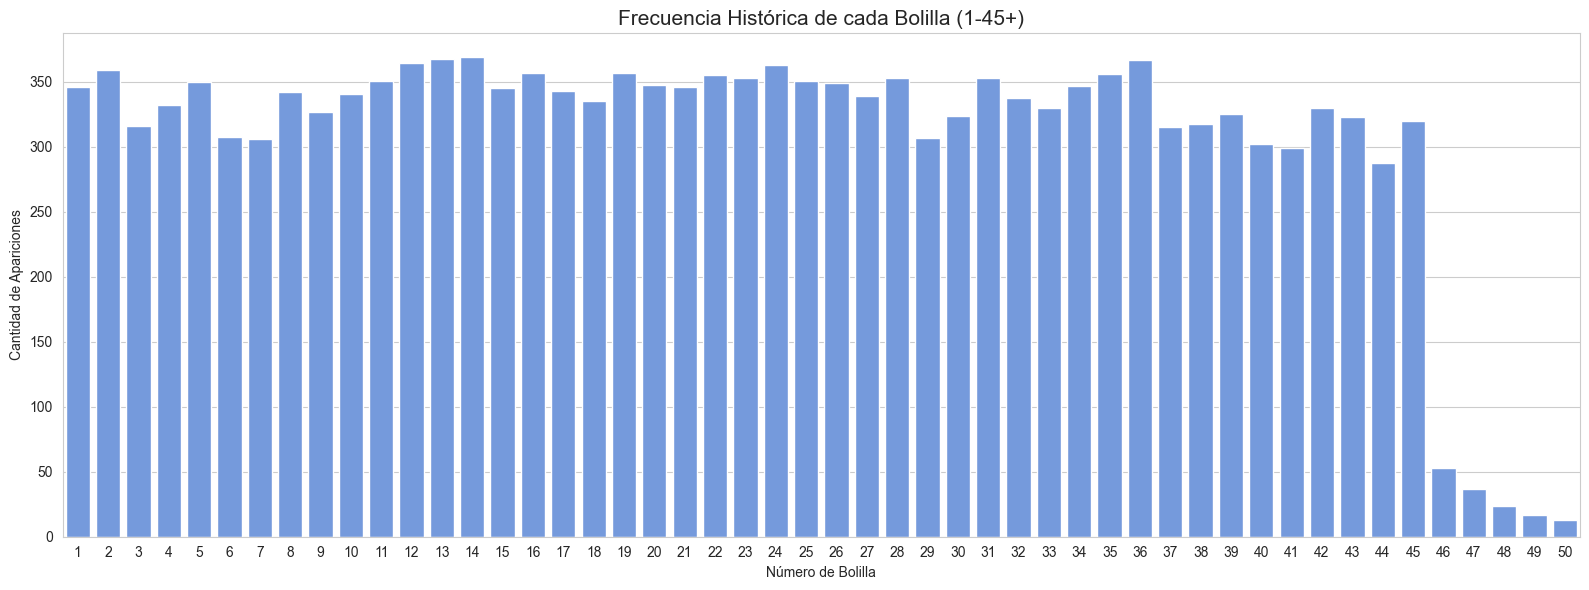

Top 10 Números más frecuentes (Calientes):
Numeros
14    369
13    368
36    367
12    365
24    363
2     359
16    357
19    357
35    356
22    355
Name: count, dtype: int64

Top 10 Números menos frecuentes (Fríos):
Numeros
29    307
7     306
40    302
41    299
44    288
46     53
47     37
48     24
49     17
50     13
Name: count, dtype: int64


In [4]:
if raw_df is not None and not raw_df.empty:
    # Aplanar todos los números sorteados
    all_numbers = df_clean['Numeros'].explode().astype(int)
    
    freq = all_numbers.value_counts().sort_index()
    freq_sorted = all_numbers.value_counts().sort_values(ascending=False)
    
    # Visualización
    plt.figure(figsize=(16, 6))
    sns.barplot(x=freq.index, y=freq.values, color='cornflowerblue')
    plt.title('Frecuencia Histórica de cada Bolilla (1-45+)', fontsize=15)
    plt.xlabel('Número de Bolilla')
    plt.ylabel('Cantidad de Apariciones')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    print("Top 10 Números más frecuentes (Calientes):")
    print(freq_sorted.head(10))
    
    print("\nTop 10 Números menos frecuentes (Fríos):")
    print(freq_sorted.tail(10))

## 4. Números que "más demoran" (Atrasos)
Calculamos hace cuántos sorteos no sale cada número.

Fecha del último sorteo analizado: 2026-03-04 00:00:00


/var/folders/sl/1vmdvj_x71d7vcvydhjxp4t80000gn/T/ipykernel_8870/4015545987.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=delays_series.index, y=delays_series.values, order=delays_series.index, palette="Reds_r")


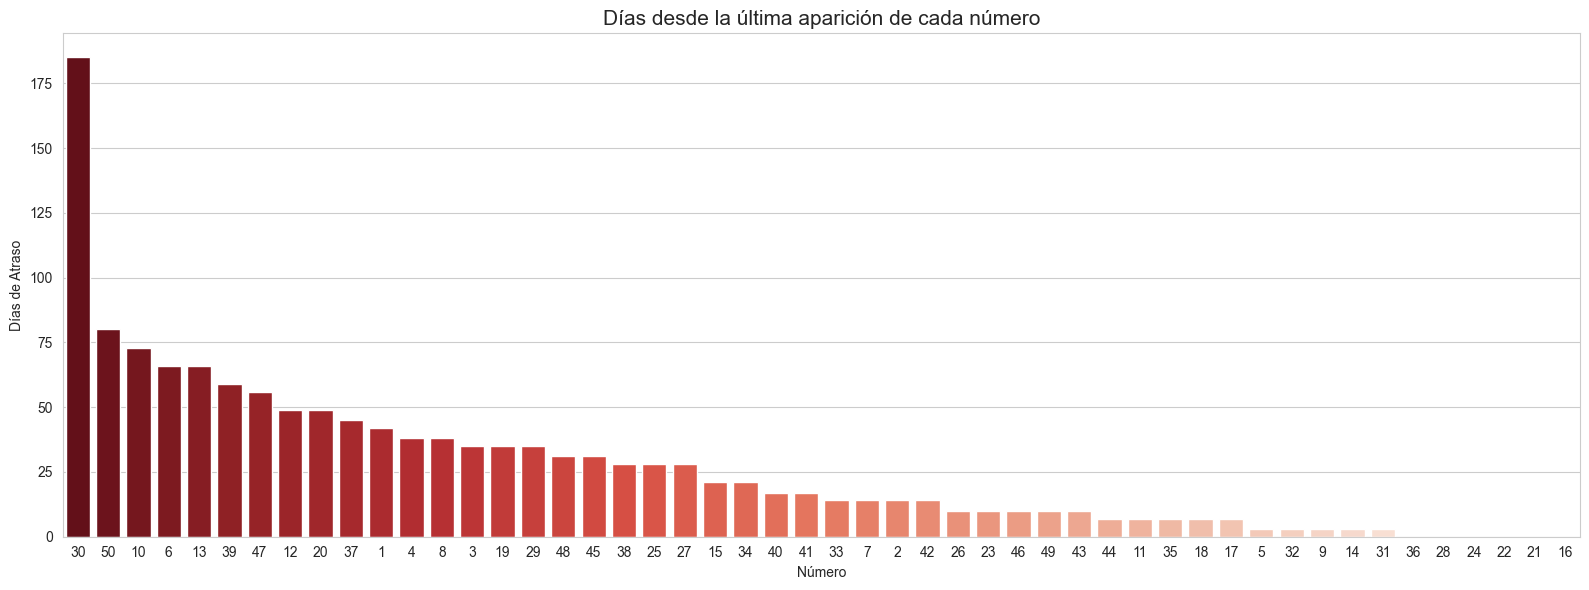

Números más atrasados (Días sin salir):
30    185
50     80
10     73
6      66
13     66
39     59
47     56
12     49
20     49
37     45
dtype: int64


In [5]:
if raw_df is not None and not raw_df.empty:
    last_draw_date = df_clean['Fecha_dt'].iloc[-1]
    print(f"Fecha del último sorteo analizado: {last_draw_date}")
    
    # Determinar el rango de bolillas (usualmente 1 a 45 o 46, a veces más históricamente)
    min_b = int(all_numbers.min())
    max_b = int(all_numbers.max())
    possible_numbers = range(min_b, max_b + 1)
    
    delays = {}
    
    # Iteramos hacia atrás para encontrar la última aparición
    # Esto es ineficiente O(N*M) pero para 2500 sorteos x 45 nums es instantáneo
    for num in possible_numbers:
        found = False
        for idx, row in df_clean.sort_values('Fecha_dt', ascending=False).iterrows():
            if num in row['Numeros']:
                days_diff = (last_draw_date - row['Fecha_dt']).days
                # Count draws back (index position roughly)
                # Pero para exactitud usamos fecha o indice reverso
                delays[num] = days_diff
                found = True
                break
        if not found:
            delays[num] = 9999 # Nunca salió (o error)
            
    delays_series = pd.Series(delays).sort_values(ascending=False)
    
    plt.figure(figsize=(16, 6))
    sns.barplot(x=delays_series.index, y=delays_series.values, order=delays_series.index, palette="Reds_r")
    plt.title('Días desde la última aparición de cada número', fontsize=15)
    plt.xlabel('Número')
    plt.ylabel('Días de Atraso')
    plt.tight_layout()
    plt.show()
    
    print("Números más atrasados (Días sin salir):")
    print(delays_series.head(10))

## 5. Pares más Comunes
¿Qué parejas de números salen juntas con mayor frecuencia?

Top 15 Pares más frecuentes:


,Par,Frecuencia
0,"(13, 15)",55
1,"(11, 23)",55
2,"(12, 17)",55
3,"(13, 34)",55
4,"(17, 36)",55
5,"(5, 21)",55
6,"(20, 27)",54
7,"(8, 24)",54
8,"(16, 34)",54
9,"(5, 25)",54


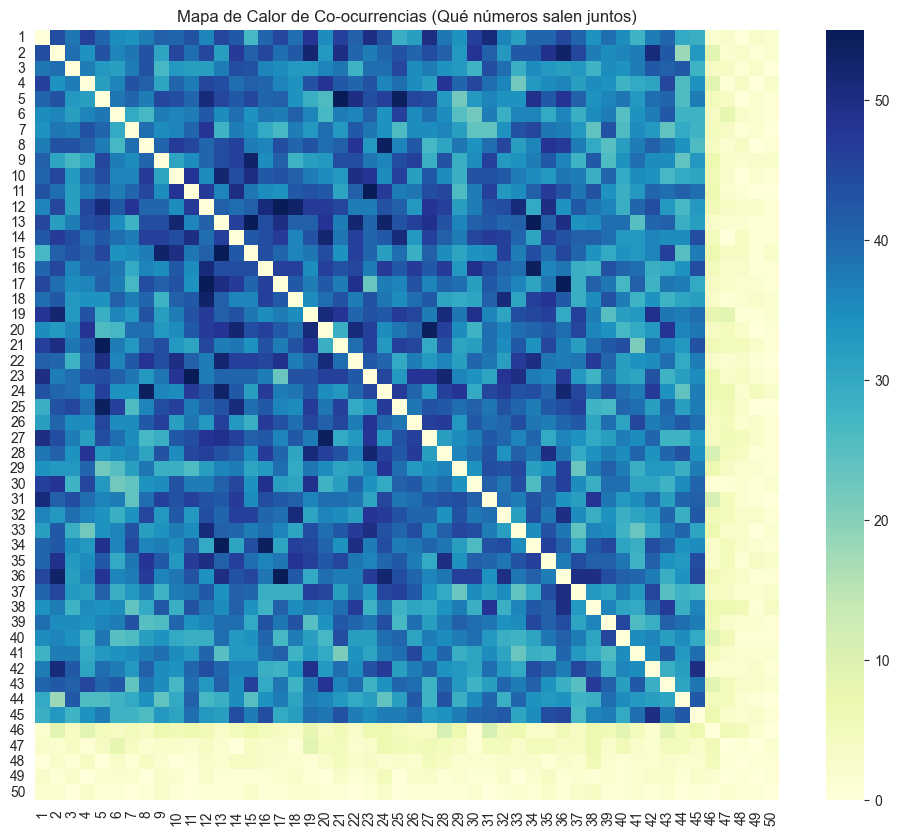

In [6]:
if raw_df is not None and not raw_df.empty:
    pair_counts = {}
    
    for nums in df_clean['Numeros']:
        # Ordenamos para que (1, 2) sea igual que (2, 1)
        pairs = list(combinations(sorted(nums), 2))
        for p in pairs:
            pair_counts[p] = pair_counts.get(p, 0) + 1
            
    # Convertir a DataFrame
    pairs_df = pd.DataFrame(list(pair_counts.items()), columns=['Par', 'Frecuencia'])
    pairs_df = pairs_df.sort_values('Frecuencia', ascending=False).reset_index(drop=True)
    
    print("Top 15 Pares más frecuentes:")
    display(pairs_df.head(15))
    
    # Matriz de calor de pares
    # Creamos matriz NxN
    size = max_b + 1
    matrix = np.zeros((size, size))
    
    for (n1, n2), count in pair_counts.items():
        matrix[n1, n2] = count
        matrix[n2, n1] = count # Simétrica
        
    plt.figure(figsize=(12, 10))
    # Cortamos filas/cols 0 si no se usan
    sns.heatmap(matrix[1:, 1:], cmap="YlGnBu", xticklabels=range(1, size), yticklabels=range(1, size))
    plt.title('Mapa de Calor de Co-ocurrencias (Qué números salen juntos)')
    plt.show()

## 6. Distribución de Pares e Impares

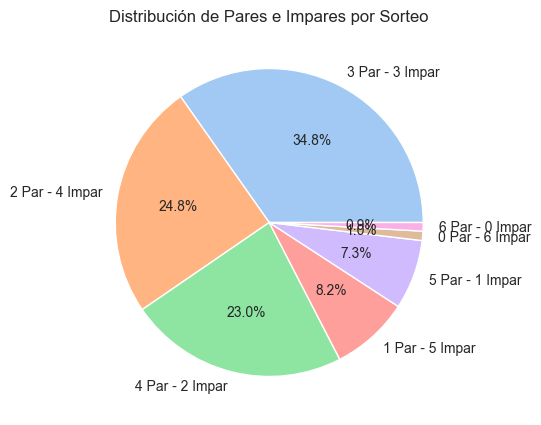

In [7]:
if raw_df is not None and not raw_df.empty:
    def count_parity(nums):
        evens = sum(1 for n in nums if n % 2 == 0)
        odds = len(nums) - evens
        return f"{evens} Par - {odds} Impar"
    
    df_clean['Paridad'] = df_clean['Numeros'].apply(count_parity)
    
    parity_counts = df_clean['Paridad'].value_counts()
    
    plt.figure(figsize=(8, 5))
    colors = sns.color_palette('pastel')[0:len(parity_counts)]
    plt.pie(parity_counts, labels=parity_counts.index, autopct='%.1f%%', colors=colors)
    plt.title('Distribución de Pares e Impares por Sorteo')
    plt.show()

## 7. Análisis de Sumas
La suma de los 6 números suele seguir una distribución normal.

Suma Promedio: 137.80
Desviación Estándar: 31.68


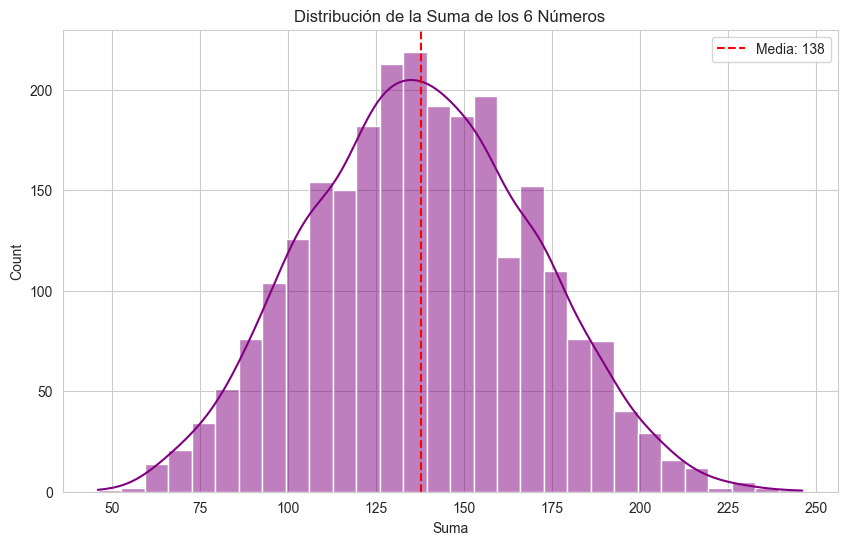

In [8]:
if raw_df is not None and not raw_df.empty:
    df_clean['Suma'] = df_clean['Numeros'].apply(sum)
    
    mean_sum = df_clean['Suma'].mean()
    std_sum = df_clean['Suma'].std()
    
    print(f"Suma Promedio: {mean_sum:.2f}")
    print(f"Desviación Estándar: {std_sum:.2f}")
    
    plt.figure(figsize=(10, 6))
    sns.histplot(df_clean['Suma'], kde=True, bins=30, color='purple')
    plt.axvline(mean_sum, color='red', linestyle='--', label=f'Media: {mean_sum:.0f}')
    plt.title('Distribución de la Suma de los 6 Números')
    plt.legend()
    plt.show()

## 8. Análisis de Saltos (Diferencias entre Bolillas)

Aquí analizamos la diferencia numérica entre las bolillas ordenadas de menor a mayor. Por ejemplo, si sale [3, 8, 15...], el primer salto es 8-3 = 5.

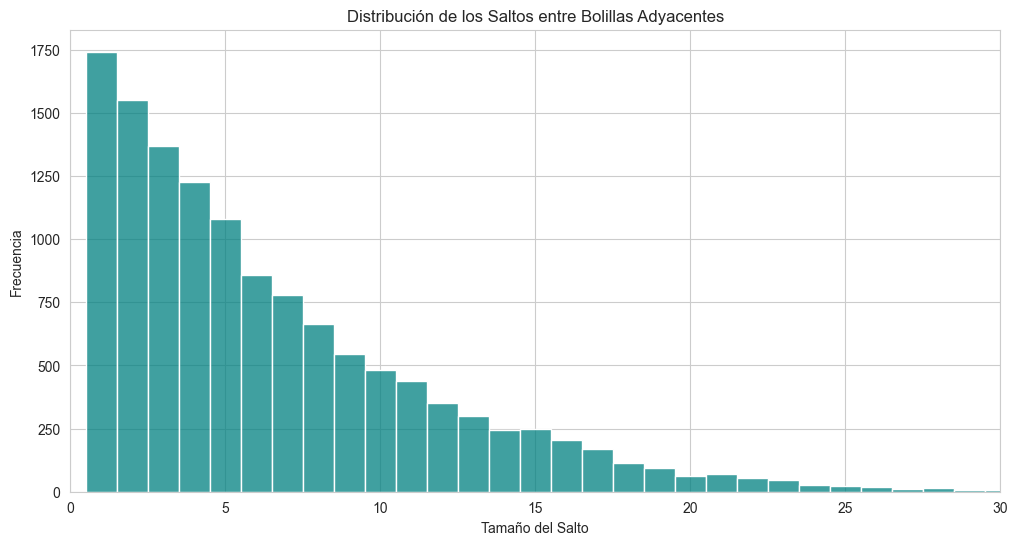

Estadísticas de Saltos:
count    12800.000000
mean         6.476016
std          5.234591
min          1.000000
25%          2.000000
50%          5.000000
75%          9.000000
max         34.000000
dtype: float64


In [9]:
if raw_df is not None and not raw_df.empty:
    # Crear columnas de deferencias
    # Usamos las columnas sorteadas B_Sort_1 ... B_Sort_6
    # df_clean tiene ['B_Sort_1', ..., 'B_Sort_6']
    
    jumps_df = pd.DataFrame(index=df_clean.index)
    
    for i in range(1, 6):
        col_next = f'B_Sort_{i+1}'
        col_curr = f'B_Sort_{i}'
        jumps_df[f'Salto_{i}'] = df_clean[col_next] - df_clean[col_curr]

    df_clean = pd.concat([df_clean, jumps_df], axis=1)
    
    # Visualizar distribución de saltos
    all_jumps = jumps_df.values.flatten()
    
    plt.figure(figsize=(12, 6))
    sns.histplot(all_jumps, discrete=True, color='teal')
    plt.title('Distribución de los Saltos entre Bolillas Adyacentes')
    plt.xlabel('Tamaño del Salto')
    plt.ylabel('Frecuencia')
    plt.xlim(0, 30)
    plt.show()
    
    print("Estadísticas de Saltos:")
    print(pd.Series(all_jumps).describe())

### Patrones de Saltos Repetidos
¿Cuántas veces ocurre que un salto se repite inmediatamente? (Ej. 3, 8, 13 -> Salto 5, luego Salto 5)

In [10]:
if raw_df is not None and not raw_df.empty:
    # Contar saltos repetidos consecutivos en una misma jugada
    # Ej: Salto_1 == Salto_2
    
    repeated_jumps_counts = 0
    total_combinations_of_jumps = len(df_clean) * 4 # 5 saltos => 4 pares de saltos adyacentes
    
    for i in range(1, 5):
        # Comparar Salto_i con Salto_{i+1}
        matches = df_clean[f'Salto_{i}'] == df_clean[f'Salto_{i+1}']
        repeated_jumps_counts += matches.sum()
        
    print(f"Total de veces que un salto se repite consecutivamente: {repeated_jumps_counts}")
    print(f"Probabilidad aproximada: {repeated_jumps_counts / total_combinations_of_jumps:.2%}")
    
    # Buscar casos extremos donde se repite 3 veces o más (patrón escalera)
    # Ej: 2, 4, 6, 8
    escaleras = df_clean[
        (df_clean['Salto_1'] == df_clean['Salto_2']) & 
        (df_clean['Salto_2'] == df_clean['Salto_3'])
    ]
    
    if not escaleras.empty:
        print("\n¡Se encontraron patrones 'Escalera' (3 saltos iguales seguidos)!")
        display(escaleras[['Fecha', 'Numeros', 'Salto_1', 'Salto_2', 'Salto_3']].head())

Total de veces que un salto se repite consecutivamente: 713
Probabilidad aproximada: 6.96%

¡Se encontraron patrones 'Escalera' (3 saltos iguales seguidos)!


,Fecha,Numeros,Salto_1,Salto_2,Salto_3
2398,16/11/1997,"[2, 7, 12, 17, 22, 31]",5,5,5
2364,12/07/1998,"[14, 17, 20, 23, 30, 39]",3,3,3
2341,20/12/1998,"[6, 38, 8, 7, 39, 9]",1,1,1
2197,23/09/2001,"[36, 20, 24, 28, 32, 42]",4,4,4
2181,13/01/2002,"[41, 8, 11, 10, 17, 9]",1,1,1


## 9. Números Consecutivos
¿Qué tan común es que salgan números seguidos (ej. 14 y 15)?

Sorteos con al menos dos números consecutivos: 1376 de 2560
Porcentaje: 53.75%


/var/folders/sl/1vmdvj_x71d7vcvydhjxp4t80000gn/T/ipykernel_8870/597842986.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=consecutive_count_per_row, palette='viridis')


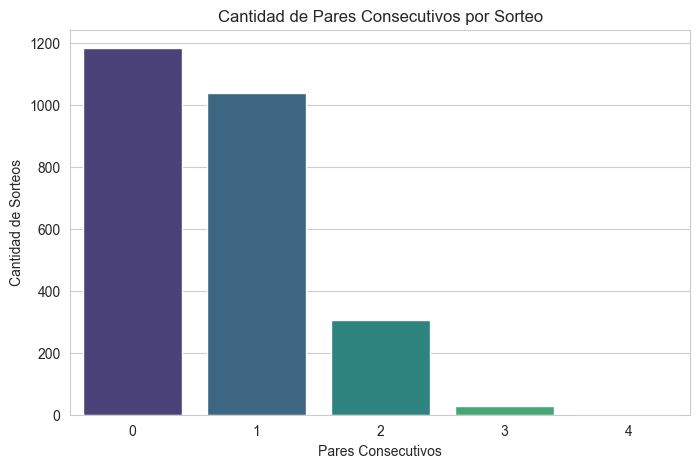

In [11]:
if raw_df is not None and not raw_df.empty:
    # Si hay un salto de 1, es un consecutivo
    has_consecutive = (jumps_df == 1).any(axis=1)
    num_consecutive = has_consecutive.sum()
    
    print(f"Sorteos con al menos dos números consecutivos: {num_consecutive} de {len(df_clean)}")
    print(f"Porcentaje: {num_consecutive / len(df_clean):.2%}")
    
    # Histograma de cuántos consecutivos hay por sorteo
    consecutive_count_per_row = (jumps_df == 1).sum(axis=1)
    
    plt.figure(figsize=(8, 5))
    sns.countplot(x=consecutive_count_per_row, palette='viridis')
    plt.title('Cantidad de Pares Consecutivos por Sorteo')
    plt.xlabel('Pares Consecutivos')
    plt.ylabel('Cantidad de Sorteos')
    plt.show()

## 10. Terminaciones (Último Dígito)
¿Hay terminaciones favoritas?

/var/folders/sl/1vmdvj_x71d7vcvydhjxp4t80000gn/T/ipykernel_8870/847982571.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ending_counts.index, y=ending_counts.values, palette='magma')


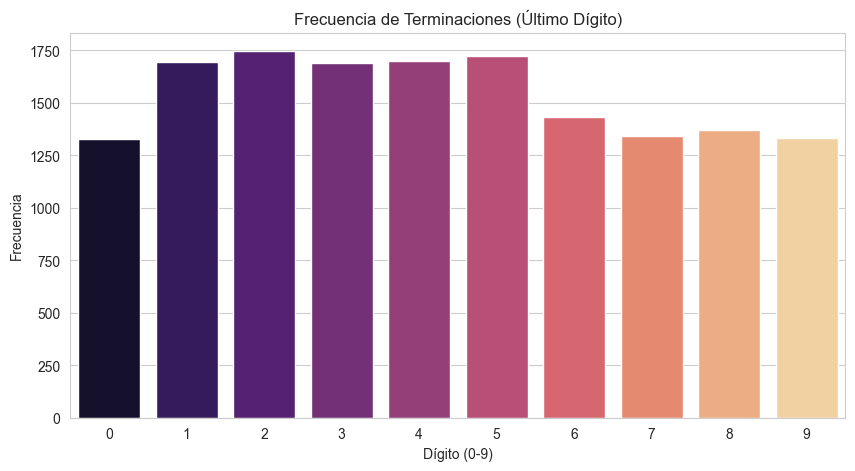

In [12]:
if raw_df is not None and not raw_df.empty:
    # Extraer último dígito de cada número
    # Aplanamos primero
    endings = all_numbers % 10
    
    ending_counts = endings.value_counts().sort_index()
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=ending_counts.index, y=ending_counts.values, palette='magma')
    plt.title('Frecuencia de Terminaciones (Último Dígito)')
    plt.xlabel('Dígito (0-9)')
    plt.ylabel('Frecuencia')
    plt.show()